##Generate your kaggle token from profile and upload the json file in the cell below

In [1]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zainabfatima7","key":"9dd1e0029bfe4546b2dc41ff40102478"}'}

##Create a directory for kaggle datasets

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

##Download the flowers dataset

In [3]:
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip flowers-recognition.zip -d flowers/

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:11<00:00, 20.2MB/s]

Archive:  flowers-recognition.zip
  inflating: flowers/flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: flowers/flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: flowers/flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: flowers/flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: flowers/flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: flowers/flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: flowers/flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: flowers/flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: flowers/flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: flowers/flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: flowers/flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: flowers/flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: flowers/flowers/daisy/10466290366_cc72e33

## CNN Architectures : VGG, Resnet, InceptionNet, XceptionNet

### UseCases : Image Feature Extraction + Transfer Learning


<br>

A Gold mine dataset for comuter vision is the ImageNet dataset. It consists of about 14 M hand-labelled annotated images which contains over 22,000 day-to-day categories. Every year ImageNet competition is hosted in which the smaller version of this dataset (with 1000 categories) is used with an aim to accurately classify the images. Many winning solutions of the ImageNet Challenge have used state of the art convolutional neural network architectures to beat the best possible accuracy thresholds. In this kernel, I have discussed these popular architectures such as VGG16, 19, ResNet, AlexNet etc. In the end, I have explained how to generate image features using pretrained models and use them in machine learning models.

## Contents

<br>

From the high level perspective, I have discussed three main components

<ul>
    <li>1. CNN Architectures   </li>
<ul>
    <li>1. 1 VGG16</li>
    <li>1.2 VGG19 </li>
    <li>1.3 InceptionNet</li>
    <li>1.4 Resnet </li>
    <li>1.5 XceptionNet</li>
</ul>
    <li>2. Image Feature Extraction  </li>
    <li>3. Transfer Learning  </li>
</ul>


## 1. CNN Architectures
## 1.1 &nbsp;&nbsp; VGG16

VGG16 was publised in 2014 and is one of the simplest (among the other cnn architectures used in Imagenet competition). It's Key Characteristics are:   

1. This network contains total 16 layers in which weights and bias parameters are learnt.    
2. A total of 13 convolutional layers are stacked one after the other and 3 dense layers for classification.     
3. The number of filters in the convolution layers follow an increasing pattern (similar to decoder architecture of autoencoder).     
4. The informative features are obtained by max pooling layers applied at different steps in the architecture.    
5. The dense layers comprises of 4096, 4096, and 1000 nodes each.   
6. The cons of this architecture are that it is slow to train and produces the model with very large size.   

The VGG16 architecture is given below:

![](https://tech.showmax.com/2017/10/convnet-architectures/image_0-8fa3b810.png)

## Implementation : VGG16
Let's see how we can create this architecture using python's keras library. The following code block shows the implementation of VGG16 in keras.


In [4]:
from keras.layers import Input, Conv2D, MaxPooling2D
from keras.layers import Dense, Flatten
from keras.models import Model

_input = Input((224,224,1))

conv1  = Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu")(_input)
conv2  = Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu")(conv1)
pool1  = MaxPooling2D((2, 2))(conv2)

conv3  = Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu")(pool1)
conv4  = Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu")(conv3)
pool2  = MaxPooling2D((2, 2))(conv4)

conv5  = Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu")(pool2)
conv6  = Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu")(conv5)
conv7  = Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu")(conv6)
pool3  = MaxPooling2D((2, 2))(conv7)

conv8  = Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu")(pool3)
conv9  = Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu")(conv8)
conv10 = Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu")(conv9)
pool4  = MaxPooling2D((2, 2))(conv10)

conv11 = Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu")(pool4)
conv12 = Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu")(conv11)
conv13 = Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu")(conv12)
pool5  = MaxPooling2D((2, 2))(conv13)

flat   = Flatten()(pool5)
dense1 = Dense(4096, activation="relu")(flat)
dense2 = Dense(4096, activation="relu")(dense1)
output = Dense(1000, activation="softmax")(dense2)

vgg16_model  = Model(inputs=_input, outputs=output)

## PreTrained Model : VGG16



Keras library also provides the pre-trained model in which one can load the saved model weights, and use them for different purposes : transfer learning, image feature extraction, and object detection. We can load the model architecture given in the library, and then add all the weights to the respective layers.

Before using the pretrained models, lets write a few functions which will be used to make some predictions. First, load some images and preprocess them.

In [5]:
from keras.applications.vgg16 import decode_predictions
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np
import os

img1 = "flowers/flowers/daisy/10172567486_2748826a8b.jpg"
img2 = "flowers/flowers/dandelion/13881700933_69a750d418_n.jpg"
img3 = "flowers/flowers/sunflower/1297092593_e573c0a3d6.jpg"
img4 = "flowers/flowers/tulip/11746367_d23a35b085_n.jpg"
imgs = [img1, img2, img3, img4]

def _load_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img

def _get_predictions(_model):
    f, ax = plt.subplots(1, 4)
    f.set_size_inches(80, 40)
    for i in range(4):
        ax[i].imshow(Image.open(imgs[i]).resize((200, 200), Image.Resampling.LANCZOS))
    plt.show()

    f, axes = plt.subplots(1, 4)
    f.set_size_inches(80, 20)
    for i,img_path in enumerate(imgs):
        img = _load_image(img_path)
        preds  = decode_predictions(_model.predict(img), top=3)[0]
        b = sns.barplot(y=[c[1] for c in preds], x=[c[2] for c in preds], color="gray", ax=axes[i])
        b.tick_params(labelsize=55)
        f.tight_layout()

Now, we can perform following steps :
1. import VGG16 architecture from keras.applications  
2. Add the saved weights to the architecture
3. Use model to perform predictions

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step


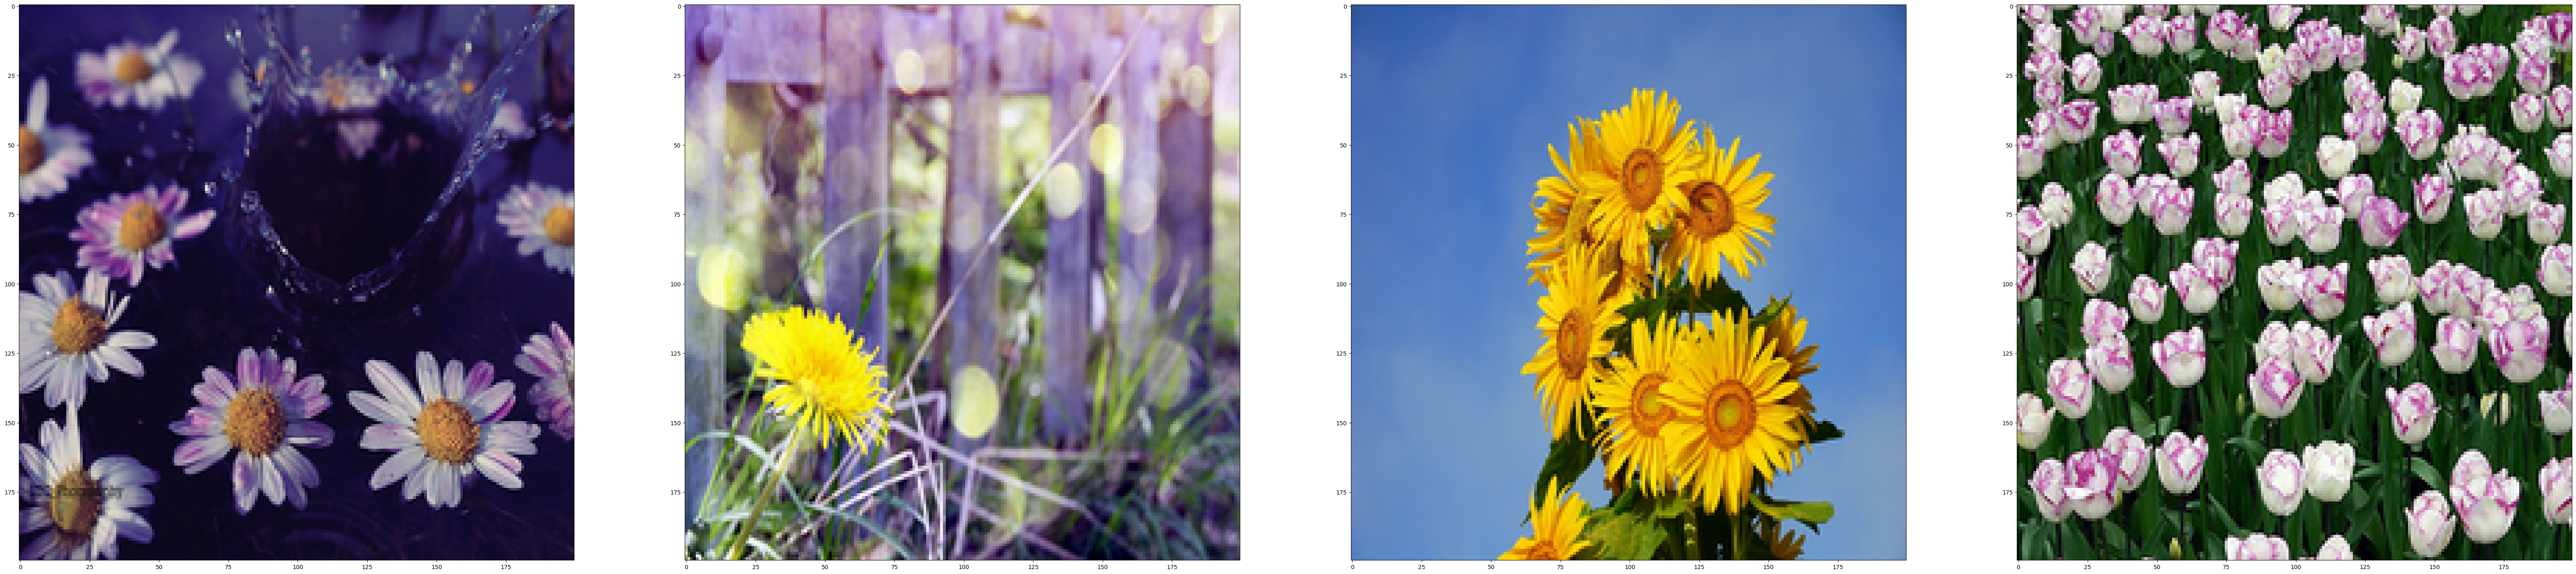

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


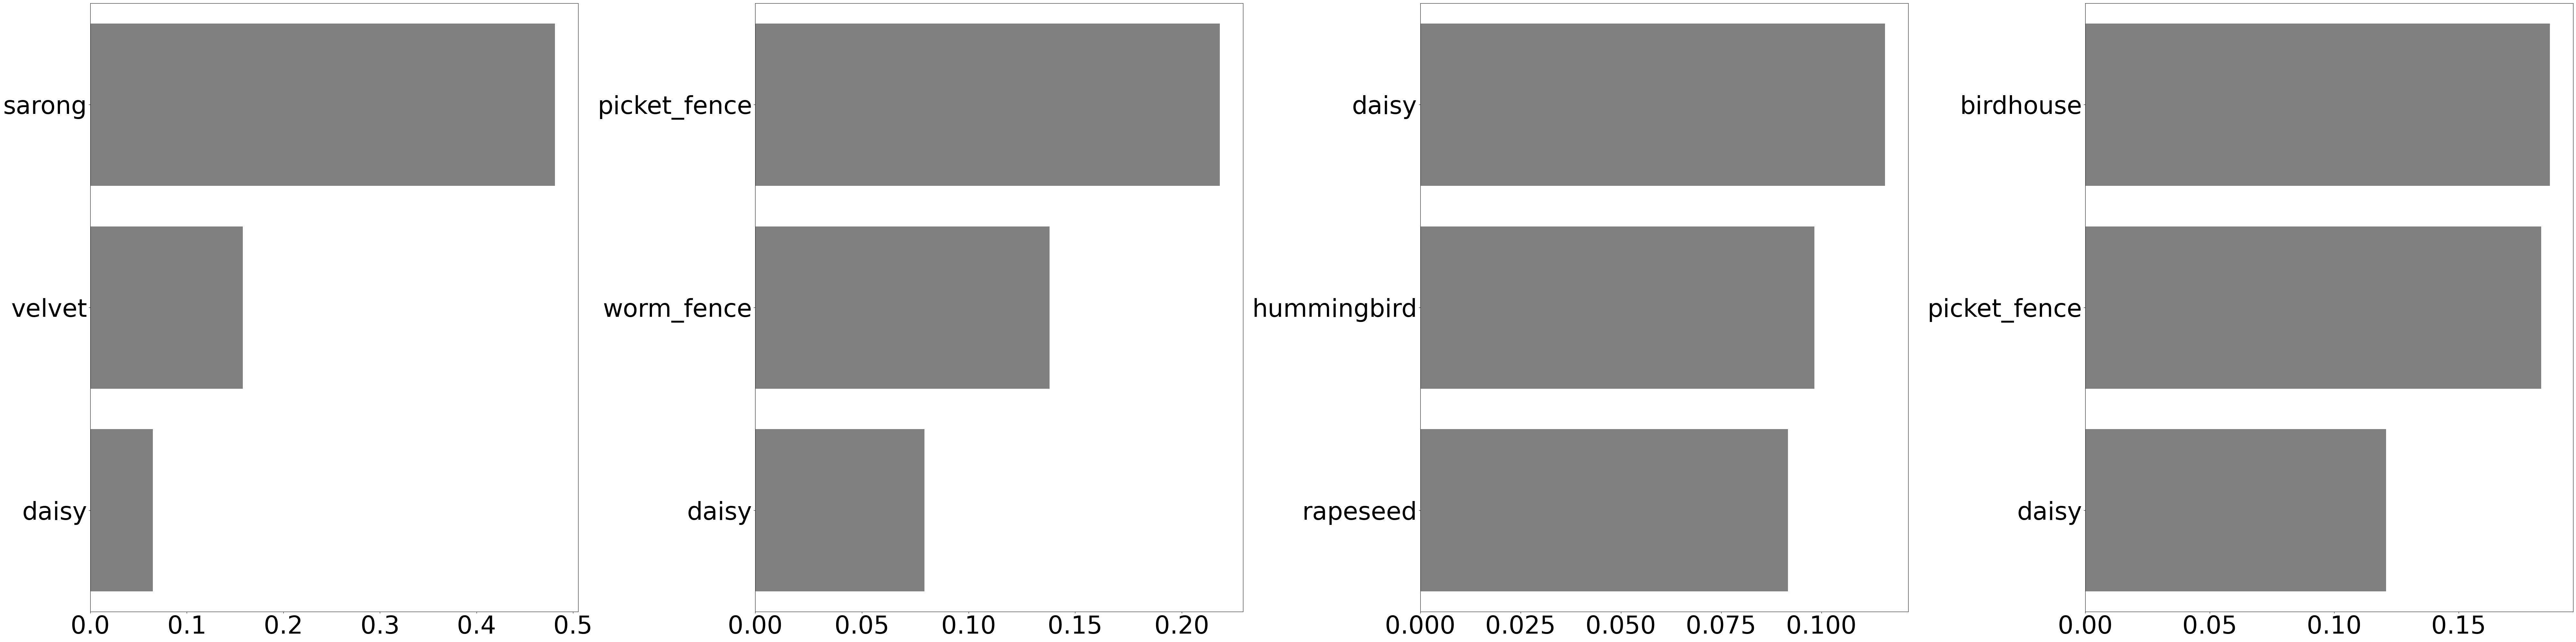

In [6]:
from keras.applications.vgg16 import VGG16
vgg16_model = VGG16(weights = 'imagenet')
_get_predictions(vgg16_model)

## 1.2 &nbsp;&nbsp; VGG19

VGG19 is a similar model architecure as VGG16 with three additional convolutional layers, it consists of a total of 16 Convolution layers and 3 dense layers.  Following is the architecture of VGG19 model. In VGG networks, the use of 3 x 3 convolutions with stride 1 gives an effective receptive filed equivalent to 7 * 7. This means there are fewer parameters to train.

![](https://cdn-images-1.medium.com/max/1600/1*cufAO77aeSWdShs3ba5ndg.jpeg)



574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step


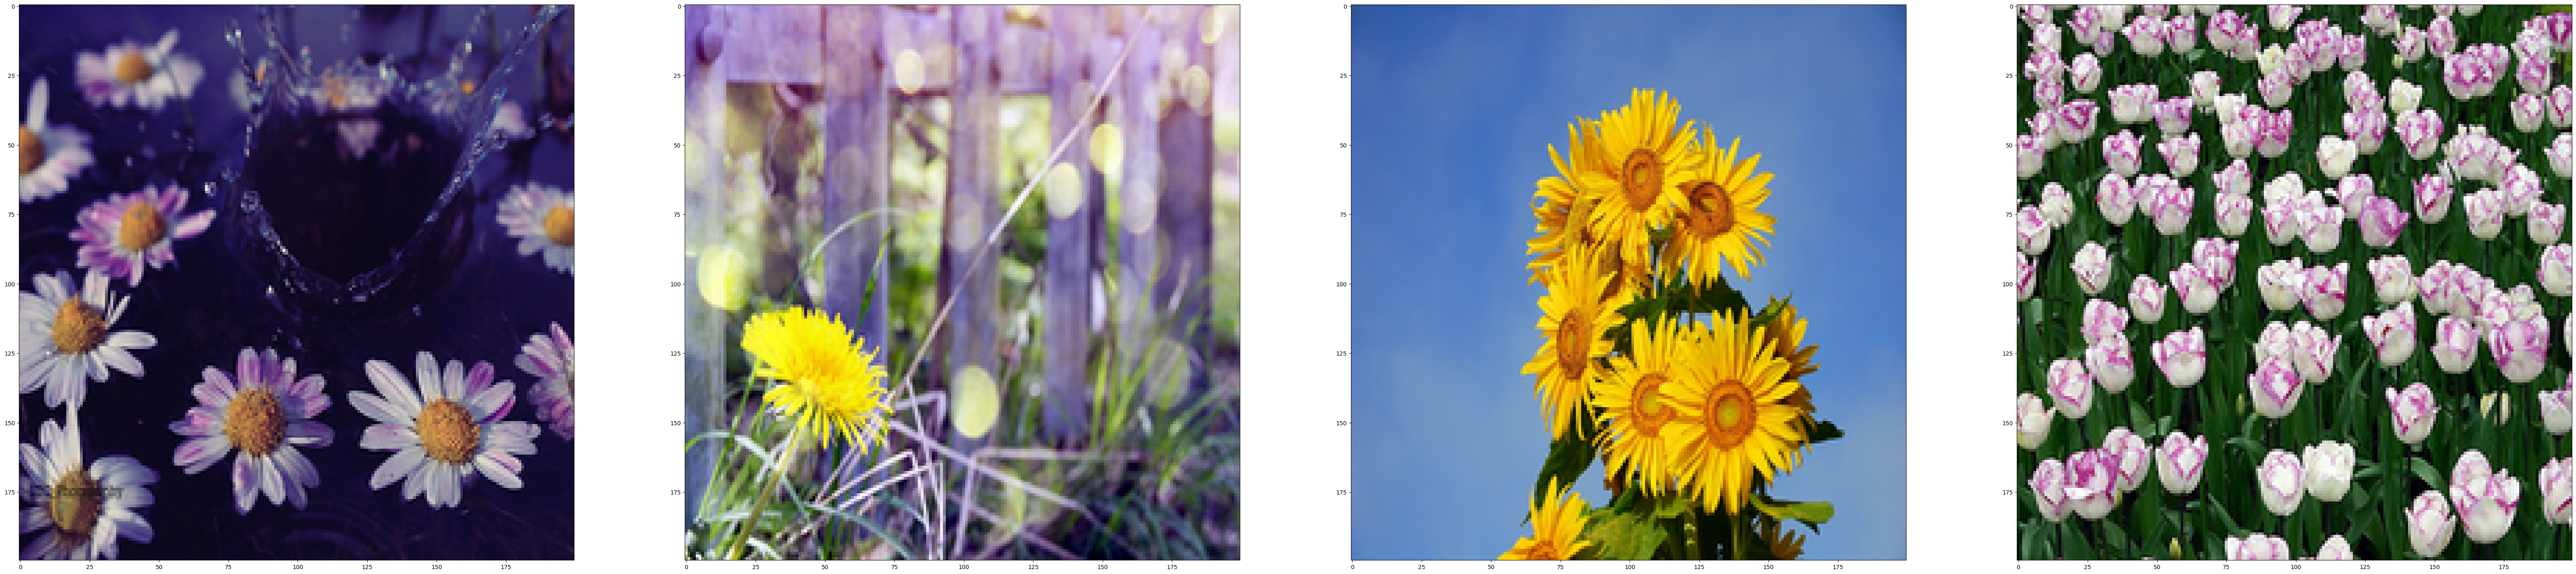

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step


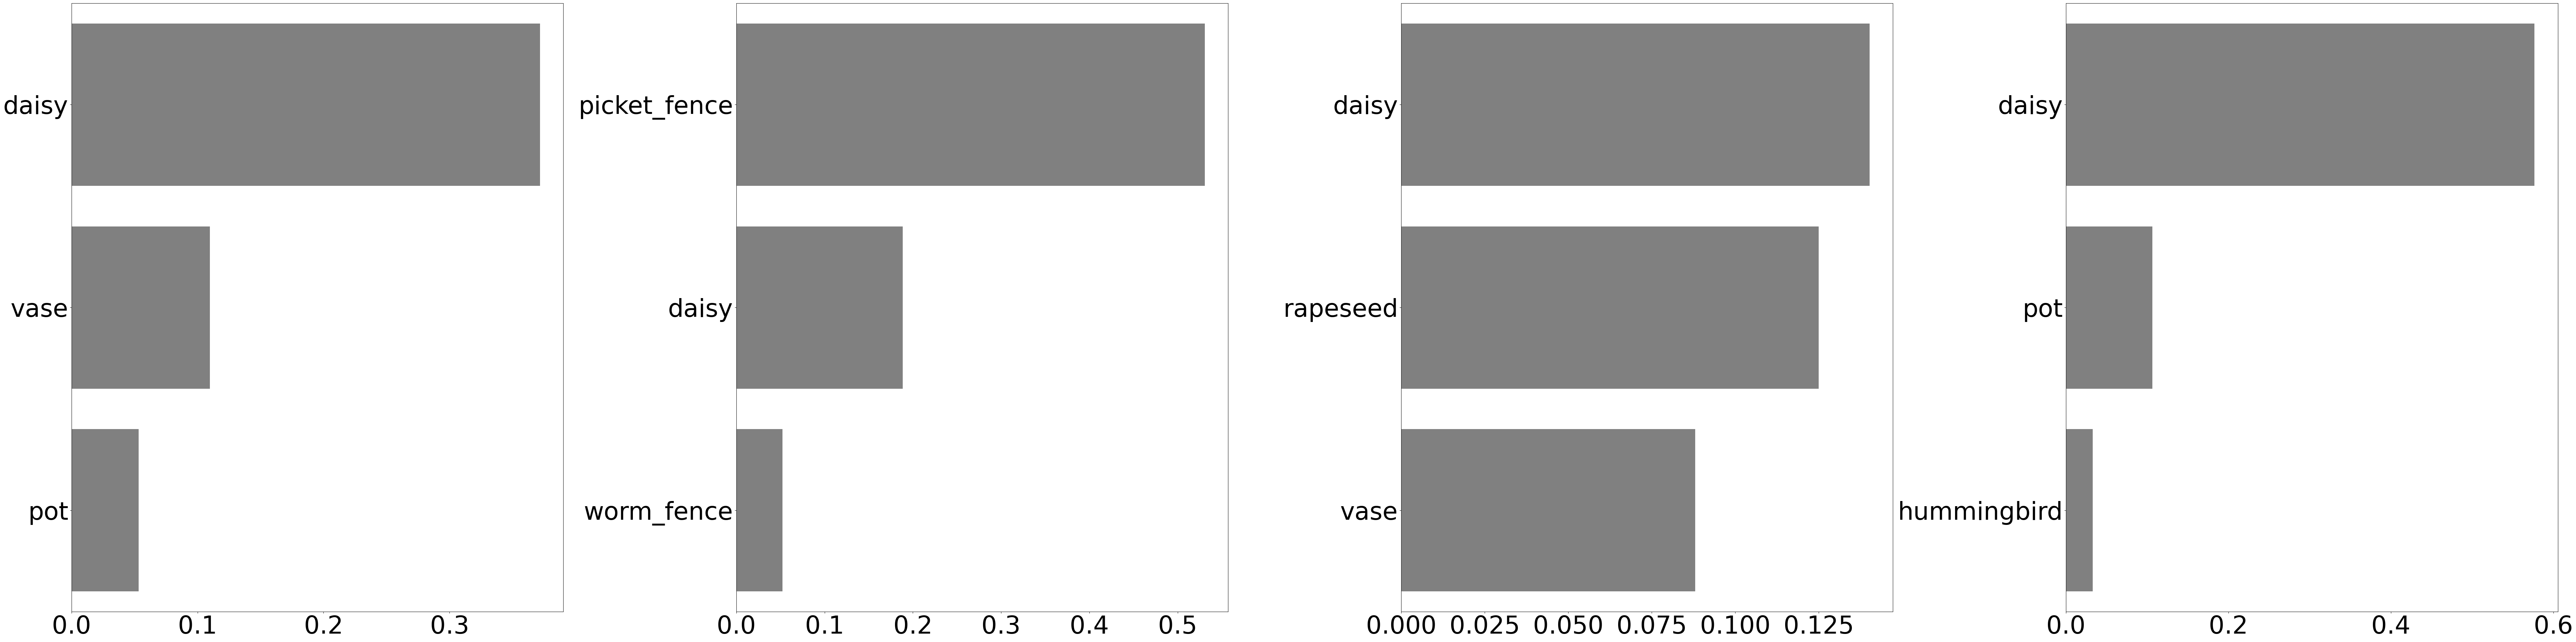

In [7]:
from keras.applications.vgg19 import VGG19
vgg19_model = VGG19(weights='imagenet')
_get_predictions(vgg19_model)

## 1.4 Resnets

Original Paper : https://arxiv.org/pdf/1512.03385.pdf

All the previous models used deep neural networks in which they stacked many convolution layers one after the other. It was learnt that deeper networks are performing better. However, it turned out that this is not really true. Following are the problems with deeper networks:

- Network becomes difficult to optimize  
- Vanishing / Exploding Gradeints  
- Degradation Problem ( accuracy first saturates and then degrades )  

### Skip Connections   

So to address these problems, authors of the resnet architecture came up with the idea of skip connections with the hypothesis that the deeper layers should be able to learn something as equal as shallower layers. A possible solution is copying the activations from shallower layers and setting additional layers to identity mapping.   These connections are enabled by skip connections which are shown in the following figure.

![](https://cdn-images-1.medium.com/max/987/1*pUyst_ciesOz_LUg0HocYg.png)

So the role of these connections is to perform identity function over the activation of shallower layer, which in-turn produces the same activation. This output is then added with the activation of the next layer. To enable these connections or essentially enable this addition operation, one need to ensure the same dimentions of convolutions through out the network, that's why resnets have same 3 by 3 convolutions throughout.

### Key Advantage

By using residual blocks in the network, one can construct networks of any depth with the hypothesis that new layers are actually helping to learn new underlying patterns in the input data. The authors of the paper were able to create the deep neural network architecture with 152 layers. The variants of Resnets such as resnet34, resnet50, resnet101 have produced the solutions with very high accuracy in Imagenet competitions.

### Why it works ?

Lets discuss why residual networks are successful and enables the addition of more and more layers without the key problems ie. without hurting the network performance.

Consider a plain neural network (A) without residual network as shown. So in the network (A) the input X is passed to this Neural Network (NN) to give the activation A1.

  <br>

![](https://i.imgur.com/9j8bKaY.png)

Now, consider a more deeper network (B) in which a residual block (with 2 extra layers and a skip connection) is added in the previous network. So now, the activation A1 is being passed to Residual Block which in turns gives new activation A3.

if there was no skip connection, then A3 was:

>  A3 = relu ( W2 . A2 + b2)              ..... (without skip connection)

where W2 and b2 are weights and bias associated with layer L2. But, with skip connection another term A1 will be passed to L2. So the equation of A3 will be modified as:

> A3 = relu ( W2 . A2 + b2 + A1)

If we use L2 regularization or the weight decay methods, they will force W2 and b2 to become close to zero. In the worst case, if these become zero, then

> A3 = relu (A1)   

because relu will output 0 for negative, A1 for positive and we know that A1 is previous activation from relu which is positive.

> A3 = A1

This means that Identitiy function is easy for residual blocks to learn. By addition of residual blocks, model complexity was not increased. As this is only copying the previous activation to the next layers. However this is only the worst case situation, but the it may turn out that these additional layers learns something useful. In that case, the network performance will improve.

Hence, adding the residual blocks / skip connections does not hurt the network performance but infact increases the chances that new layers will learn something useful.

Let's look at the usage using pre-trained resnet 50 model.

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


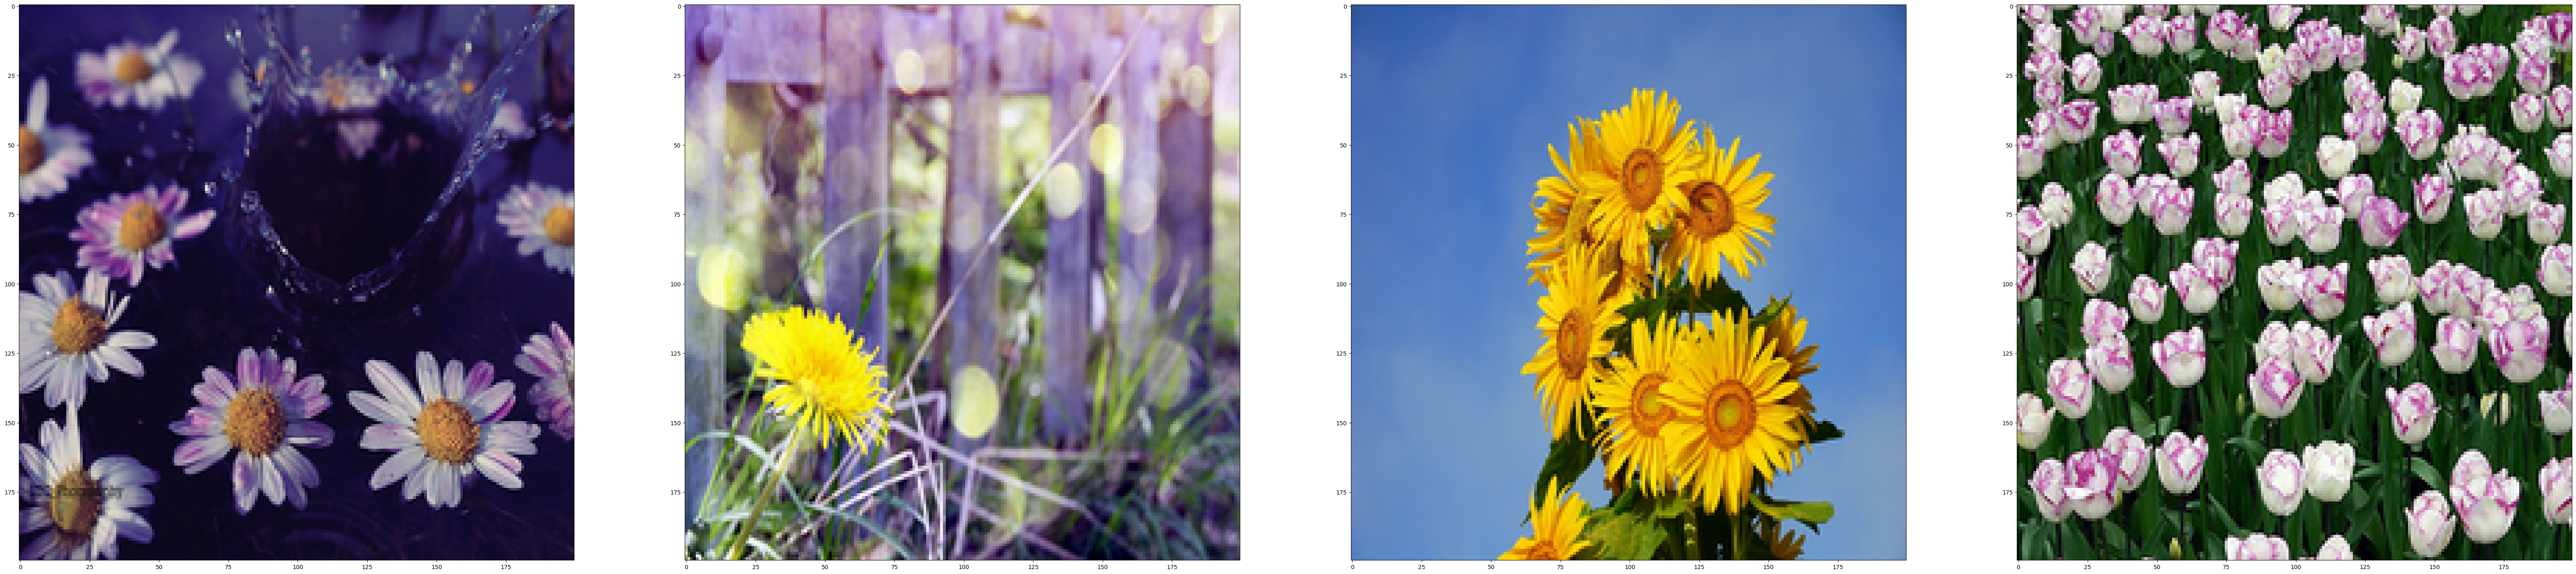

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


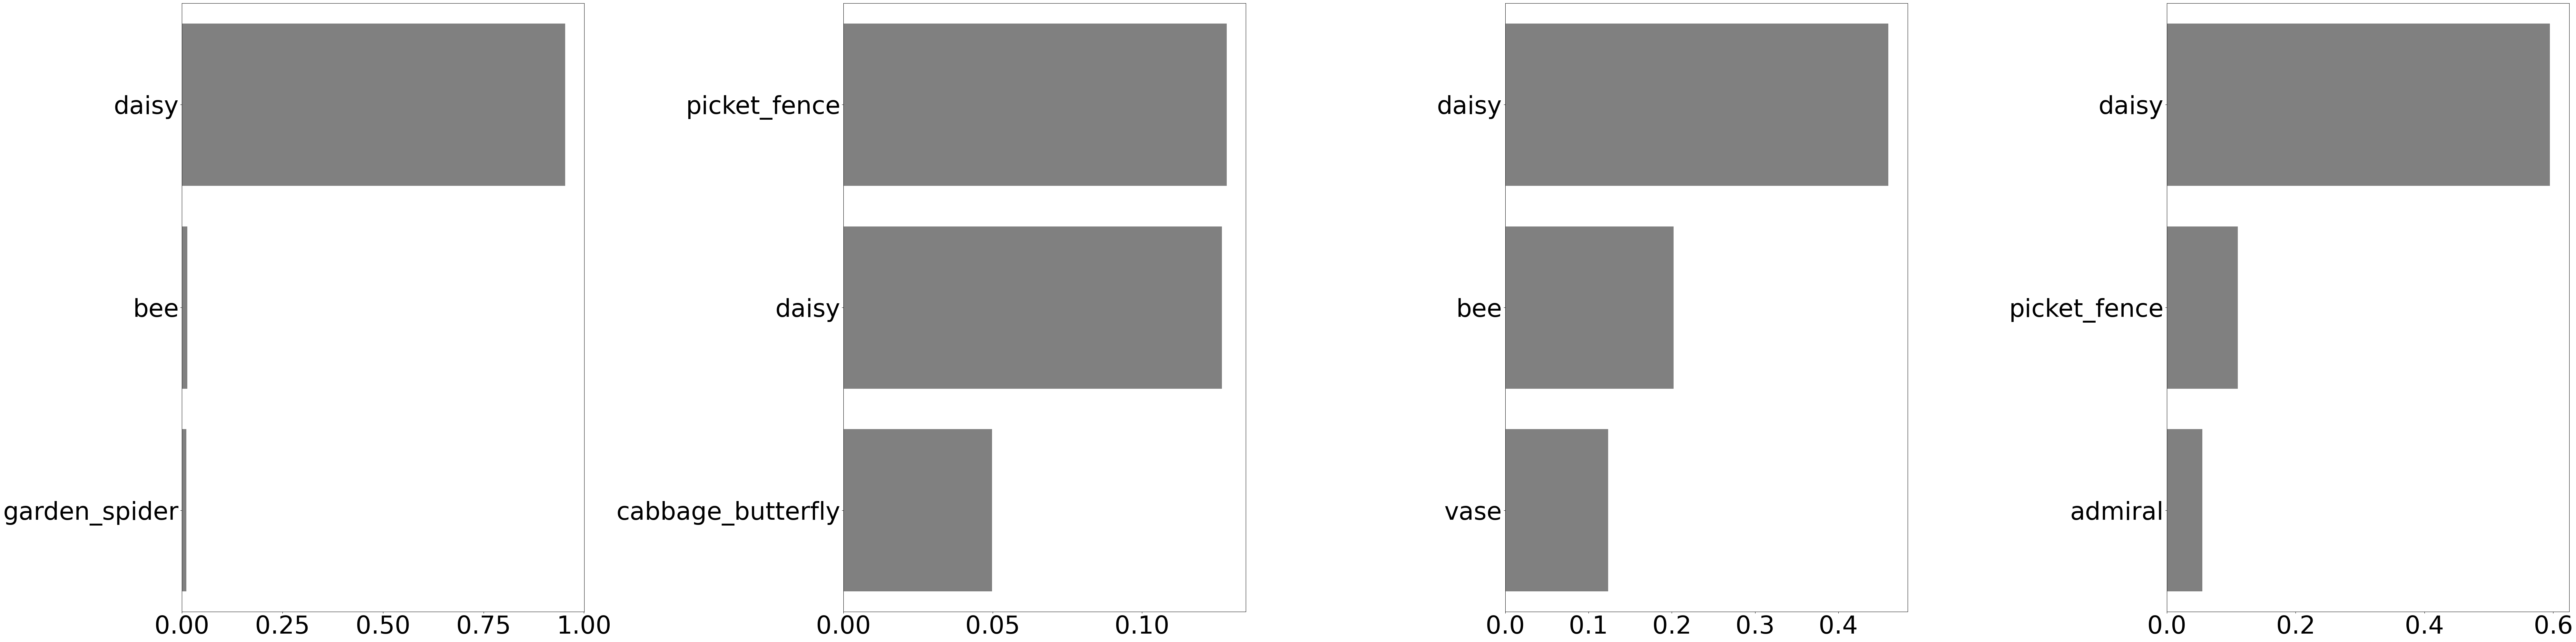

In [8]:
from keras.applications.resnet50 import ResNet50
resnet_model = ResNet50(weights='imagenet')
_get_predictions(resnet_model)

## &nbsp;&nbsp; 1.3 InceptionNets

Also known as GoogleNet consists of total 22 layers and was the winning model of 2014 image net challenge.

- Inception modules are the fundamental block of InceptionNets. The key idea of inception module is to design good local network topology (network within a network)  
- These modules or blocks acts as the multi-level feature extractor in which convolutions of different sizes are obtained to create a diversified feature map
- The inception modules also consists of 1 x 1 convolution blocks whose role is to perform dimentionaltiy reduction.  
- By performing the 1x1 convolution, the inception block preserves the spatial dimentions but reduces the depth. So the overall network's dimentions are not increased exponentially.  
- Apart from the regular output layer, this network also consists of two auxillary classification outputs which are used to inject gradients at lower layers.  

<br><br>

The inception module is shown in the following figure:  

![](https://hackathonprojects.files.wordpress.com/2016/09/inception_implement.png?w=649&h=337)

The complete architecture is shown below:

![](https://cdn-images-1.medium.com/max/2000/1*uXfC5fcbDsL0TJG4T8PsVw.png)

<br>

### Pre-Trained Model : InceptionV3

##Inception V3 accepts a different input image shape, let's change that.

In [9]:
from keras.applications.vgg16 import decode_predictions
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np
import os

img1 = "flowers/flowers/daisy/10172567486_2748826a8b.jpg"
img2 = "flowers/flowers/dandelion/13881700933_69a750d418_n.jpg"
img3 = "flowers/flowers/sunflower/1297092593_e573c0a3d6.jpg"
img4 = "flowers/flowers/tulip/11746367_d23a35b085_n.jpg"
imgs = [img1, img2, img3, img4]

def _load_image(img_path):
    img = image.load_img(img_path, target_size=(299, 299))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img

def _get_predictions(_model):
    f, ax = plt.subplots(1, 4)
    f.set_size_inches(80, 40)
    for i in range(4):
        ax[i].imshow(Image.open(imgs[i]).resize((200, 200), Image.Resampling.LANCZOS))
    plt.show()

    f, axes = plt.subplots(1, 4)
    f.set_size_inches(80, 20)
    for i,img_path in enumerate(imgs):
        img = _load_image(img_path)
        preds  = decode_predictions(_model.predict(img), top=3)[0]
        b = sns.barplot(y=[c[1] for c in preds], x=[c[2] for c in preds], color="gray", ax=axes[i])
        b.tick_params(labelsize=55)
        f.tight_layout()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


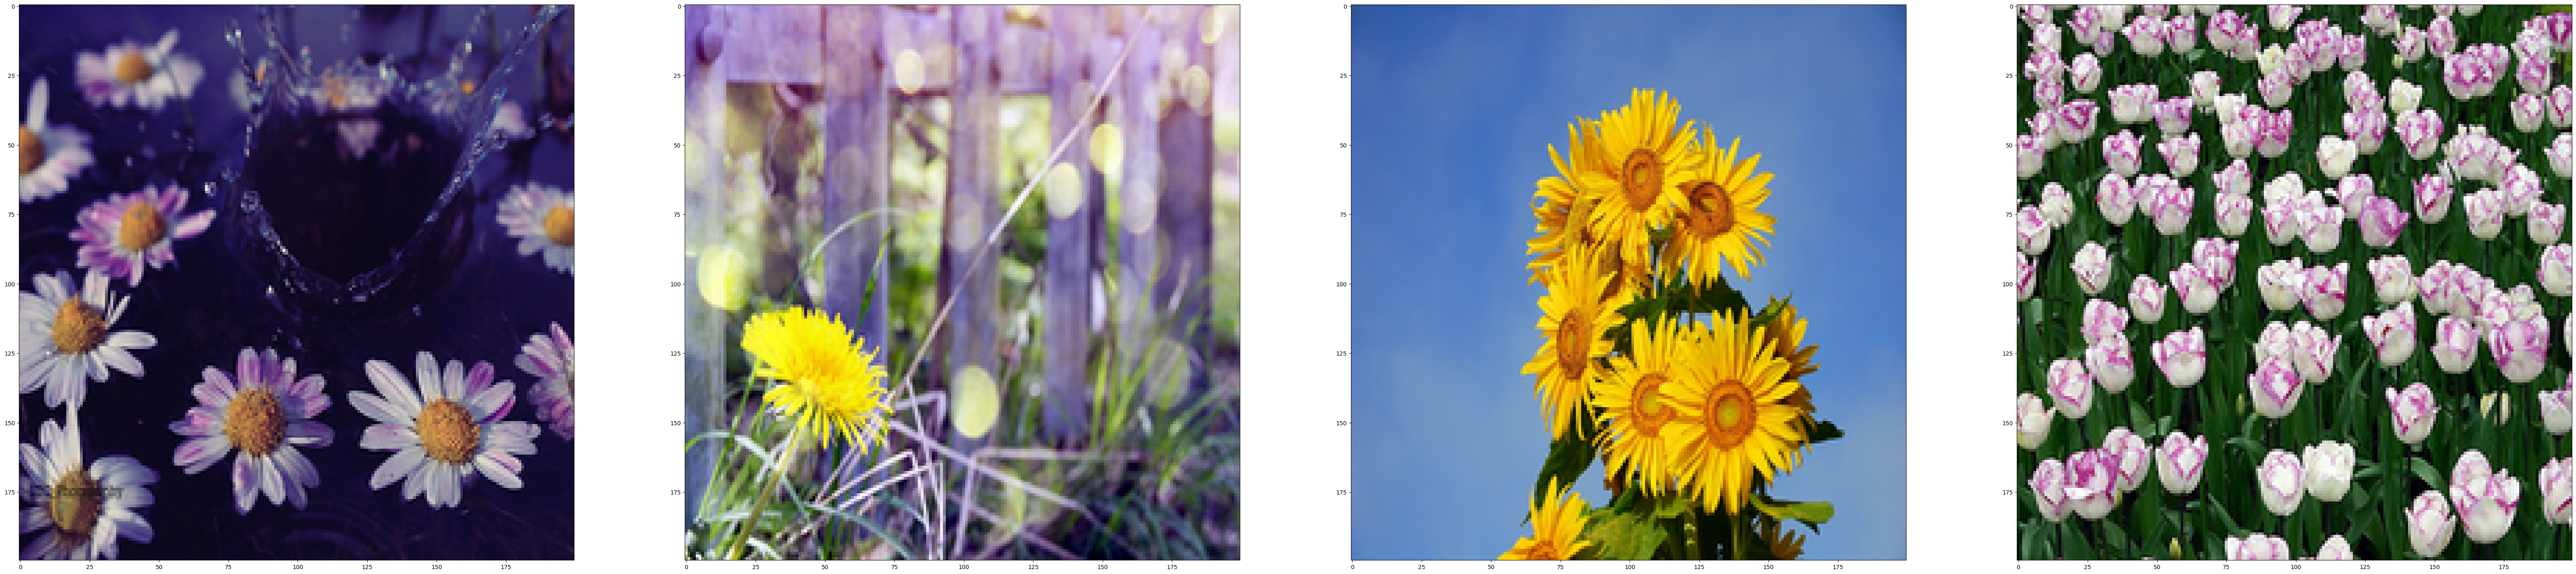

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


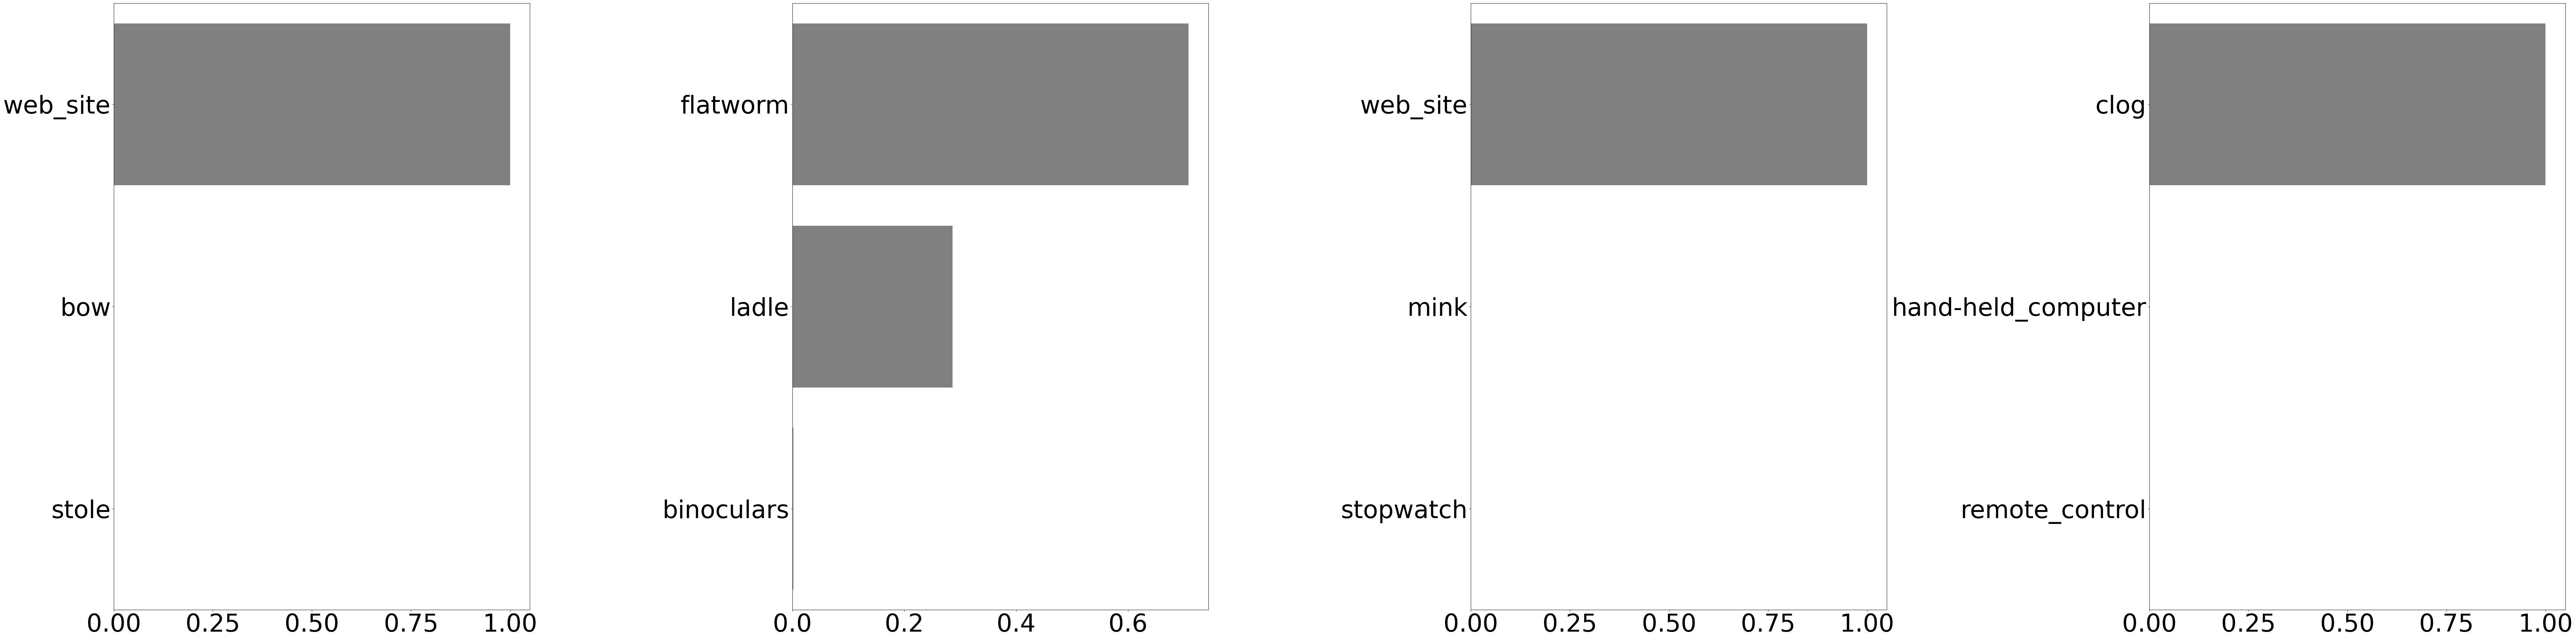

In [10]:
from keras.applications.inception_v3 import InceptionV3
inception_model = InceptionV3(weights='imagenet')
_get_predictions(inception_model)

#Activity

##Your task is to define the model architecture for VGG19 model.

In [13]:
from keras.layers import Input, Conv2D, MaxPooling2D
from keras.layers import Dense, Flatten
from keras.models import Model

_input = Input((224,224,1))

# Block 1
conv1 = Conv2D(64, (3,3), padding="same", activation="relu")(_input)
conv2 = Conv2D(64, (3,3), padding="same", activation="relu")(conv1)
pool1 = MaxPooling2D((2,2))(conv2)

# Block 2
conv3 = Conv2D(128, (3,3), padding="same", activation="relu")(pool1)
conv4 = Conv2D(128, (3,3), padding="same", activation="relu")(conv3)
pool2 = MaxPooling2D((2,2))(conv4)

# Block 3
conv5 = Conv2D(256, (3,3), padding="same", activation="relu")(pool2)
conv6 = Conv2D(256, (3,3), padding="same", activation="relu")(conv5)
conv7 = Conv2D(256, (3,3), padding="same", activation="relu")(conv6)
conv8 = Conv2D(256, (3,3), padding="same", activation="relu")(conv7)
pool3 = MaxPooling2D((2,2))(conv8)

# Block 4
conv9  = Conv2D(512, (3,3), padding="same", activation="relu")(pool3)
conv10 = Conv2D(512, (3,3), padding="same", activation="relu")(conv9)
conv11 = Conv2D(512, (3,3), padding="same", activation="relu")(conv10)
conv12 = Conv2D(512, (3,3), padding="same", activation="relu")(conv11)
pool4  = MaxPooling2D((2,2))(conv12)

# Block 5
conv13 = Conv2D(512, (3,3), padding="same", activation="relu")(pool4)
conv14 = Conv2D(512, (3,3), padding="same", activation="relu")(conv13)
conv15 = Conv2D(512, (3,3), padding="same", activation="relu")(conv14)
conv16 = Conv2D(512, (3,3), padding="same", activation="relu")(conv15)
pool5  = MaxPooling2D((2,2))(conv16)

# Fully Connected Layers
flat   = Flatten()(pool5)
dense1 = Dense(4096, activation="relu")(flat)
dense2 = Dense(4096, activation="relu")(dense1)
output = Dense(1000, activation="softmax")(dense2)

vgg19_model = Model(inputs=_input, outputs=output)

# Display model summary
vgg19_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_123 (Conv2D)             │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_124 (Conv2D)             │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_125 (Conv2D)             │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_126 (Conv2D)             │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_128 (Conv2D)             │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_129 (Conv2D)             │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_130 (Conv2D)             │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_131 (Conv2D)             │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_132 (Conv2D)             │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_133 (Conv2D)             │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_134 (Conv2D)             │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_135 (Conv2D)             │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_136 (Conv2D)             │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_137 (Conv2D)             │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_138 (Conv2D)             │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,31

 Total params: 143,666,088 (548.04 MB)

 Trainable params: 143,666,088 (548.04 MB)

 Non-trainable params: 0 (0.00 B)

VGG19 extends VGG16 by adding three additional convolutional layers, enabling it to learn more complex image features while maintaining the same overall design of 3×3 convolution kernels, ReLU activations, max-pooling layers, and three fully connected layers.